## **MATRIZ DE PESOS ESPACIALES W: ÍNDICE DE MORAN Y LISA**

- Se realiza la matriz de pesos espaciales con el fin de encontrar si existe una dependencia espacial en la frecuencia de movimientos en masa en la cuenca.

- Para construir la matriz se aplicaron dos métodos una matriz de tipo **Queen** (vecindad por contigüidad: comparten borde o vértice) y una matriz de tipo **K vecinos más cercanos** (cada slope unit tiene exactamente 6 vecinos más cercanos por distancia).

- Se evaluaron por medio del Indice de Moran y LISA (Local Indicators of Spatial Autocorrelation) con el fin de observar si existe autocorrelación espacial global y patrones locales de agrupamiento.

- Si el Indice de Moran es fuerte y significativo con ambas W: nos aseguramos que hay autocorrelación espacial.

- LISA nos puede decir en que partes se estan dando clusters de muchos o pocos movimientos en masa y donde hay outlier.

In [1]:
# %% =========================
# 0) Librerías
# =========================
import numpy as np
import pandas as pd
import geopandas as gpd

import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

# %% =========================
# 1) Leer capa (GeoPackage)
# =========================
path_gpkg = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
layer_in  = "slope_units_agg"

gdf = gpd.read_file(path_gpkg, layer=layer_in)
print(gdf.shape)
print(gdf.columns)

(57524, 14)
Index(['index', 'area', 'cluster4', 'zona', 'n_mm', 'slope_mean', 'slope_std',
       'aspect_mean', 'aspect_std', 'geologia', 'cobertura', 'mm', 'si_no',
       'geometry'],
      dtype='object')


### POR QUE Y_LOG = LOG(N_MM + 1)?

- n_mm presenta muchos ceros y unos pocos valores muy altos,
- Esto evita que unas cuantas slope units con numerosos deslizamientos dominen el análisis.
- Muchas técnicas estadísticas (regresiones, pruebas, etc.) funcionan mejor cuando la variable no es tan asimétrica.
- Moran’s I asume normalidad en su aproximación de prueba, por lo que la transformación mejora su comportamiento.
- la interpretación y la normalidad del test pueden ser peores,
- Se usa log(n_mm + 1) para manejar los ceros, reducir la asimetría y obtener una variable más estable y adecuada para los modelos.


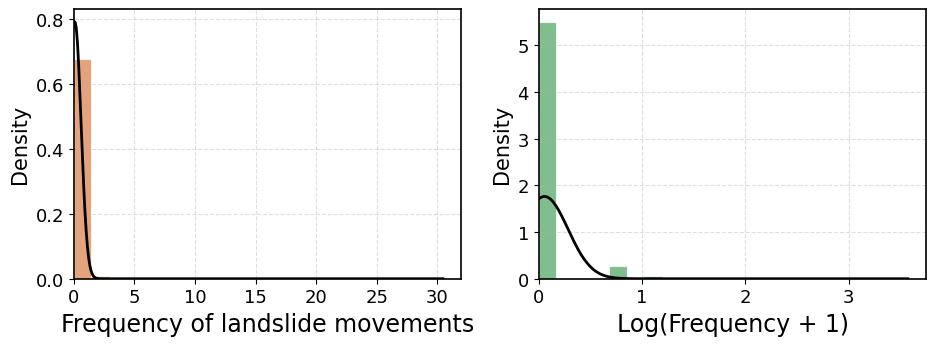

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import geopandas as gpd

# %% =========================
# 1) Leer capa (GeoPackage)
# =========================
path_gpkg = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
layer_in  = "slope_units_agg"

gdf = gpd.read_file(path_gpkg, layer=layer_in)

gdf['log_n_mm'] = np.log1p(gdf['n_mm'])

# =========================
# Función de ploteo estética
# =========================
def plot_histogram(data, xlabel, subplot_index, bar_color="#4C72B0"):
    ax = plt.subplot(1, 2, subplot_index)

    # Histograma
    ax.hist(
        data,
        bins=20,
        density=True,
        color=bar_color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.8
    )

    # Ajuste Gaussiano
    mu, std = norm.fit(data)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(max(0, xmin), xmax, 300)
    ax.plot(x, norm.pdf(x, mu, std), color="black", lw=2)

    # Estética general
    ax.set_xlim(left=0)
    ax.set_xlabel(xlabel, fontsize=17)
    ax.set_ylabel("Density", fontsize=15)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, linestyle="--", alpha=0.4)

    # Spines limpias
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

# =========================
# Final figure
# =========================
plt.figure(figsize=(11, 3.5))

plot_histogram(
    gdf["n_mm"].dropna(),
    "Frequency of landslide movements",
    1,
    bar_color="#DD8452"   # sober orange
)

plot_histogram(
    gdf["log_n_mm"].dropna(),
    "Log(Frequency + 1)",
    2,
    bar_color="#55A868"   # sober green
)

# Adjust layout and save figure
#plt.savefig('/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Figures/figFinal/Fig2.png', dpi=500, bbox_inches='tight')
plt.show()
 

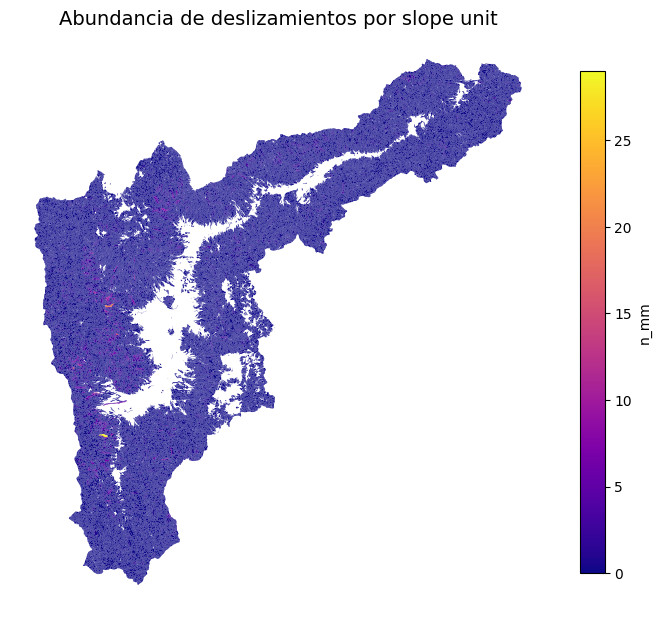

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

gdf.plot(
    column="n_mm",
    cmap="plasma",
    linewidth=0,
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "n_mm",
        "shrink": 0.75
    }
)

ax.set_title("Abundancia de deslizamientos por slope unit", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

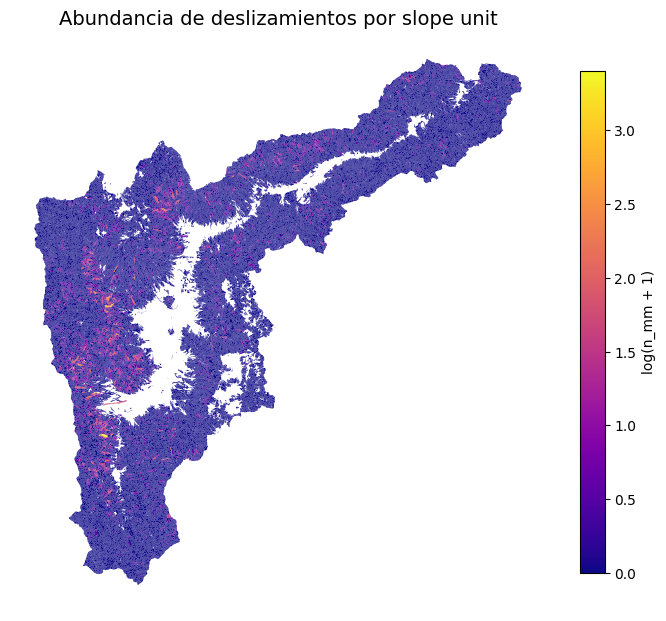

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

gdf.plot(
    column="log_n_mm",
    cmap="plasma",
    linewidth=0,
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "log(n_mm + 1)",
        "shrink": 0.75
    }
)

ax.set_title("Abundancia de deslizamientos por slope unit", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()


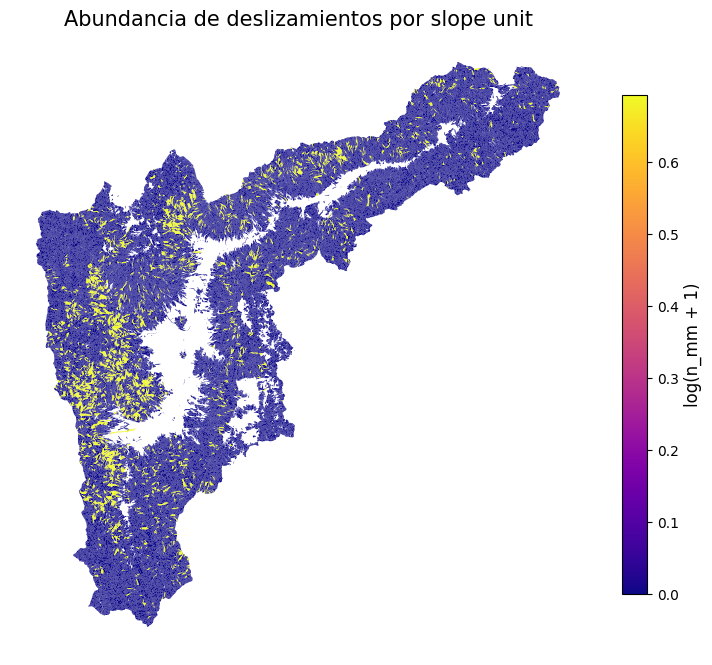

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(7.5, 7))

# Normalización (opcional pero recomendable)
norm = mpl.colors.Normalize(
    vmin=gdf["log_n_mm"].min(),
    vmax=gdf["log_n_mm"].quantile(0.98)  # evita que outliers dominen
)

gdf.plot(
    column="log_n_mm",
    cmap="plasma",
    linewidth=0,
    ax=ax,
    norm=norm
)

# Colorbar manual (más limpia)
sm = mpl.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
cbar.set_label("log(n_mm + 1)", fontsize=12)

ax.set_title("Abundancia de deslizamientos por slope unit", fontsize=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## **MATRIZ DE PESOS ESPACIALES W: TIPO QUEEN Y TIPO K VECINOS**


In [4]:
# %% =========================
# 2) Paquetes espaciales (PySAL)
# =========================
# pip install libpysal esda splot mapclassify

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local

import matplotlib.pyplot as plt

# (opcional, para mapas bonitos)
from splot.esda import lisa_cluster
import mapclassify

# %% =========================
# 3) Asegurar geometría y CRS proyectado
# =========================
gdf = gdf[gdf.geometry.notna()].copy()
gdf = gdf[gdf.is_valid].copy()

# Si está en WGS84 (EPSG:4326), PROYECTA.
# Para Medellín/Valle de Aburrá, MAGNA-SIRGAS / Colombia Oeste suele ser EPSG:3116.
# (si tú ya usas otro CRS oficial del proyecto, reemplázalo)
if gdf.crs is None:
    raise ValueError("Tu GeoDataFrame no tiene CRS definido. Asigna gdf.set_crs(...).")

if gdf.crs.to_epsg() == 4326:
    gdf = gdf.to_crs(epsg=3116)

# Variable respuesta
y = gdf["log_n_mm"].astype(float).values

# %% =========================
# 4) Matrices de pesos espaciales W
# =========================
# 4.1 Queen (contigüidad)
wQ = Queen.from_dataframe(gdf, ids=gdf.index.to_list())
wQ.transform = "R"  # row-standardized

print("Queen:")
print("  n =", wQ.n)
print("  componentes conexas =", wQ.n_components)
print("  % islas (sin vecinos) =", 100*len(wQ.islands)/wQ.n)

# 4.2 KNN (k=6) por centroides
# Nota: en KNN no debes tener geometrías raras; usa centroides en CRS proyectado
centroids = gdf.geometry.centroid
coords = list(zip(centroids.x, centroids.y))

wK = KNN.from_array(coords, k=6)
wK.transform = "R"

print("\nKNN k=6:")
print("  n =", wK.n)
print("  componentes conexas =", wK.n_components)
print("  % islas =", 100*len(wK.islands)/wK.n)

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 207 disconnected components.
 There are 141 islands with ids: 125, 162, 311, 1481, 1869, 1940, 2244, 2943, 3563, 3670, 3777, 4316, 4424, 5112, 5311, 5367, 5378, 6268, 6835, 8327, 8562, 8641, 8793, 8920, 10709, 11631, 12831, 13000, 13296, 13960, 14259, 14744, 14749, 14823, 15634, 15853, 17891, 18370, 19607, 20182, 20271, 20286, 20363, 21120, 21817, 22008, 22280, 22516, 22809, 23215, 23383, 24216, 24332, 24348, 24399, 24426, 24844, 24980, 25004, 25163, 25189, 25862, 26119, 27461, 27491, 29089, 29621, 29664, 29770, 29854, 29928, 30455, 30666, 30742, 30875, 31060, 31222, 31514, 32339, 32346, 33157, 33200, 33649, 34014, 34505, 35216, 35334, 35718, 36914, 37260, 37600, 37709, 38339, 38702, 38761, 39290, 39540, 39823, 40236, 40543, 40544, 41017, 41301, 41624, 41638, 41938, 42850, 43847, 43951, 44020, 45083, 45326, 47106, 47261, 47686, 49106,

('WARNING: ', 125, ' is an island (no neighbors)')
('WARNING: ', 162, ' is an island (no neighbors)')
('WARNING: ', 311, ' is an island (no neighbors)')
('WARNING: ', 1481, ' is an island (no neighbors)')
('WARNING: ', 1869, ' is an island (no neighbors)')
('WARNING: ', 1940, ' is an island (no neighbors)')
('WARNING: ', 2244, ' is an island (no neighbors)')
('WARNING: ', 2943, ' is an island (no neighbors)')
('WARNING: ', 3563, ' is an island (no neighbors)')
('WARNING: ', 3670, ' is an island (no neighbors)')
('WARNING: ', 3777, ' is an island (no neighbors)')
('WARNING: ', 4316, ' is an island (no neighbors)')
('WARNING: ', 4424, ' is an island (no neighbors)')
('WARNING: ', 5112, ' is an island (no neighbors)')
('WARNING: ', 5311, ' is an island (no neighbors)')
('WARNING: ', 5367, ' is an island (no neighbors)')
('WARNING: ', 5378, ' is an island (no neighbors)')
('WARNING: ', 6268, ' is an island (no neighbors)')
('WARNING: ', 6835, ' is an island (no neighbors)')
('WARNING: ', 8

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  warnings.warn(message)



KNN k=6:
  n = 57405
  componentes conexas = 2
  % islas = 0.0


- Si Queen tiene muchas islas, eso NO significa que esté mal.
- Solo significa que hay polígonos que no tocan a nadie (o huecos/gaps).
- Para Moran/LISA puedes usar una de estas estrategias:
- dejar Queen y aceptar islas (PySAL lo maneja, pero reduce n efectivo localmente)
- o preferir KNN para garantizar conectividad y comparabilidad

### **INDICE DE MORAN**

In [7]:

# %% =========================
# 5) Moran global (permuta para p-valor robusto)
# =========================
mQ = Moran(y, wQ, permutations=999)
mK = Moran(y, wK, permutations=999)

print("\n=== Moran Global ===")
print(f"Queen: I = {mQ.I:.4f} | p_perm = {mQ.p_sim:.4g} | z_perm = {mQ.z_sim:.3f}")
print(f"KNN6:  I = {mK.I:.4f} | p_perm = {mK.p_sim:.4g} | z_perm = {mK.z_sim:.3f}")


=== Moran Global ===
Queen: I = 0.2133 | p_perm = 0.001 | z_perm = 77.989
KNN6:  I = 0.1900 | p_perm = 0.001 | z_perm = 85.037


In [8]:
# %% =========================
# 6) LISA (Moran local) + clústeres HH/LL/HL/LH
# =========================
# Importante: LISA hace MUCHAS pruebas (una por polígono).
# p_sim es p-valor por permutación por SU; ojo con falsos positivos.
lQ = Moran_Local(y, wQ, permutations=999)
lK = Moran_Local(y, wK, permutations=999)

# Guardar resultados en gdf
gdf["lisa_p_Q"] = lQ.p_sim
gdf["lisa_I_Q"] = lQ.Is
gdf["lisa_q_Q"] = lQ.q  # 1 HH, 2 LH, 3 LL, 4 HL (convención PySAL)

gdf["lisa_p_K"] = lK.p_sim
gdf["lisa_I_K"] = lK.Is
gdf["lisa_q_K"] = lK.q

# Máscara de significancia (tú puedes usar 0.05, 0.01, etc.)
alpha = 0.05
sigQ = gdf["lisa_p_Q"] < alpha
sigK = gdf["lisa_p_K"] < alpha

# Crear etiqueta de clúster (solo donde es significativo)
def cluster_label(q, sig):
    if not sig:
        return "No sig."
    return {1:"HH", 2:"LH", 3:"LL", 4:"HL"}.get(int(q), "No sig.")

gdf["cluster_Q"] = [cluster_label(q, s) for q, s in zip(gdf["lisa_q_Q"], sigQ)]
gdf["cluster_K"] = [cluster_label(q, s) for q, s in zip(gdf["lisa_q_K"], sigK)]

print("\nConteos LISA (Queen):")
print(gdf["cluster_Q"].value_counts())

print("\nConteos LISA (KNN6):")
print(gdf["cluster_K"].value_counts())

/home/oisanchezp/geo_env/lib/python3.8/site-packages/esda/moran.py:1059: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim



Conteos LISA (Queen):
cluster_Q
No sig.    52443
LH          3327
HH          1297
HL           194
LL           144
Name: count, dtype: int64

Conteos LISA (KNN6):
cluster_K
No sig.    53774
LH          2291
HH          1140
HL           200
Name: count, dtype: int64


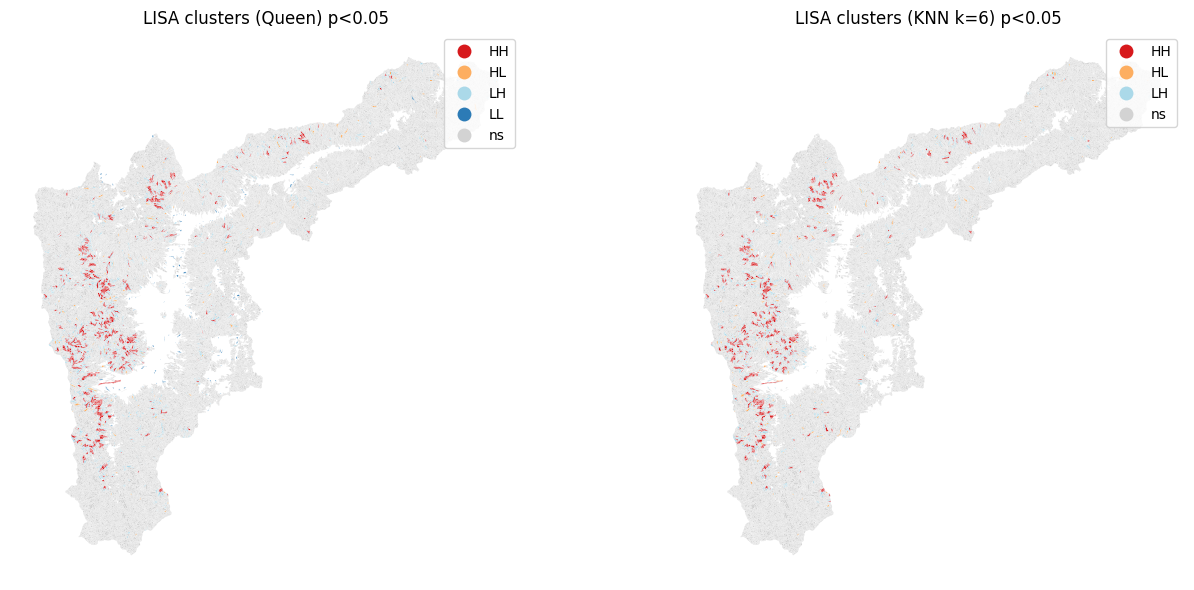

In [9]:
# %% =========================
# 7) Mapas LISA (rápidos)
# =========================
# Opción A: mapa con splot (muy práctico)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

lisa_cluster(lQ, gdf, p=alpha, ax=ax[0])
ax[0].set_title(f"LISA clusters (Queen) p<{alpha}")

lisa_cluster(lK, gdf, p=alpha, ax=ax[1])
ax[1].set_title(f"LISA clusters (KNN k=6) p<{alpha}")

for a in ax:
    a.set_axis_off()

plt.tight_layout()
plt.show()

# %% =========================
# 8) (Opcional) Guardar a geopackage con resultados
# =========================
# out = "/home/oisanchezp/Thesis/data/processed/slope_units_lisa.gpkg"
# gdf.to_file(out, layer="lisa", driver="GPKG")

*Los resultados evidencian una autocorrelación espacial positiva y estadísticamente significativa en la abundancia de deslizamientos a escala de slope unit. Tanto la matriz de contigüidad Queen como la matriz de vecinos más cercanos (k=6) muestran valores consistentes del índice de Moran, confirmando que los deslizamientos tienden a agruparse espacialmente. El análisis LISA revela la presencia de clústeres locales de alta inestabilidad (HH), así como outliers espaciales, lo que sugiere una fuerte heterogeneidad espacial asociada a controles geomorfológicos y posiblemente antrópicos.*

In [10]:
# =========================
# Variables respuesta
# =========================

# 1) Continua sin transformar
gdf["n_mm_raw"] = gdf["n_mm"].astype(float)

# 2) Binaria (presencia / ausencia)
gdf["mm_bin"] = (gdf["n_mm"] > 0).astype(int)


In [11]:
from esda.moran import Moran, Moran_Local

def spatial_diagnostics(y, w, name=""):
    y = np.asarray(y).astype(float)

    moran = Moran(y, w, permutations=999)
    lisa  = Moran_Local(y, w, permutations=999)

    out = {
        "name": name,
        "I": moran.I,
        "p": moran.p_sim,
        "z": moran.z_sim,
        "lisa_q": lisa.q,
        "lisa_p": lisa.p_sim
    }
    return out


results = {}

results["BIN"] = spatial_diagnostics(
    gdf["mm_bin"].values,
    wK,
    name="Binaria"
)

results["RAW"] = spatial_diagnostics(
    gdf["n_mm_raw"].values,
    wK,
    name="n_mm sin transformar"
)

results["LOG"] = spatial_diagnostics(
    gdf["log_n_mm"].values,
    wK,
    name="log(n_mm + 1)"
)

for k, r in results.items():
    print(f"\n=== {r['name']} ===")
    print(f"I = {r['I']:.3f} | p = {r['p']:.4g} | z = {r['z']:.2f}")



=== Binaria ===
I = 0.171 | p = 0.001 | z = 74.96

=== n_mm sin transformar ===
I = 0.172 | p = 0.001 | z = 74.62

=== log(n_mm + 1) ===
I = 0.190 | p = 0.001 | z = 78.01


In [12]:
def lisa_counts(lisa_q, lisa_p, alpha=0.05):
    labels = []
    for q, p in zip(lisa_q, lisa_p):
        if p >= alpha:
            labels.append("No sig.")
        else:
            labels.append({1:"HH", 2:"LH", 3:"LL", 4:"HL"}.get(q, "No sig."))
    return pd.Series(labels).value_counts()

for k, r in results.items():
    print(f"\nLISA clusters ({r['name']}):")
    print(lisa_counts(r["lisa_q"], r["lisa_p"]))



LISA clusters (Binaria):
No sig.    51523
LH          3500
HL          1228
HH          1154
Name: count, dtype: int64

LISA clusters (n_mm sin transformar):
No sig.    52898
LH          2392
HL          1228
HH           887
Name: count, dtype: int64

LISA clusters (log(n_mm + 1)):
No sig.    53753
LH          2300
HH          1152
HL           200
Name: count, dtype: int64


*El análisis comparativo muestra que la autocorrelación espacial es más débil cuando los deslizamientos se representan como una variable binaria, y más fuerte cuando se considera su frecuencia. Sin embargo, la variable sin transformar está dominada por valores extremos. La transformación logarítmica ofrece un equilibrio adecuado, preservando la estructura espacial y permitiendo identificar clústeres locales robustos mediante LISA. Por esta razón, log(n_mm + 1) se adopta como variable principal en los análisis espaciales posteriores.*

Moran I = 0.190, p = 0.001


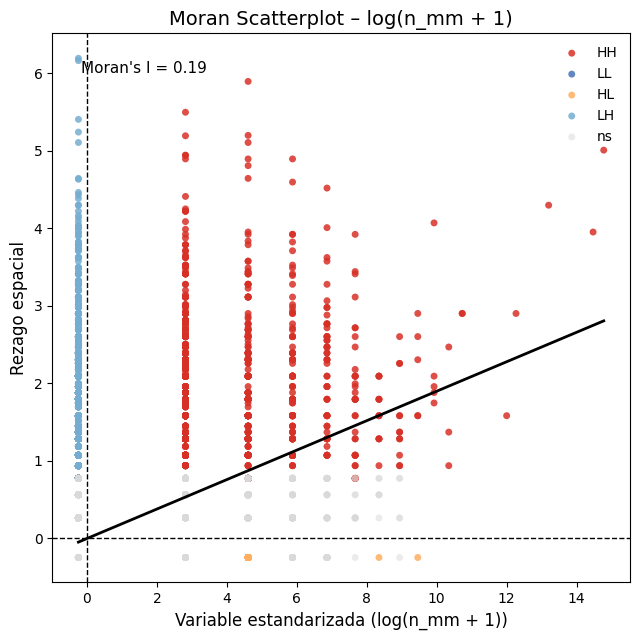

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from esda.moran import Moran, Moran_Local
from libpysal.weights.spatial_lag import lag_spatial

# Variable
y = gdf["log_n_mm"].values.astype(float)

# Estandarizar (z-score)
y_std = (y - y.mean()) / y.std()

# Rezago espacial
Wy = lag_spatial(wK, y_std)

moran = Moran(y_std, wK, permutations=999)
lisa  = Moran_Local(y_std, wK, permutations=999)

print(f"Moran I = {moran.I:.3f}, p = {moran.p_sim:.4g}")

alpha = 0.05

labels = np.full(len(y_std), "ns", dtype=object)

for i, (q, p) in enumerate(zip(lisa.q, lisa.p_sim)):
    if p < alpha:
        labels[i] = {1:"HH", 2:"LH", 3:"LL", 4:"HL"}[q]

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# Colores
colors = {
    "HH": "#d73027",  # rojo
    "LL": "#4575b4",  # azul
    "HL": "#fdae61",  # naranja
    "LH": "#74add1",  # celeste
    "ns": "#d9d9d9"   # gris
}

# Plot por grupo
for lab, col in colors.items():
    idx = labels == lab
    ax.scatter(
        y_std[idx],
        Wy[idx],
        s=25,
        c=col,
        alpha=0.85 if lab != "ns" else 0.5,
        label=lab,
        edgecolor="none"
    )

# Líneas de referencia
ax.axhline(0, color="k", linestyle="--", lw=1)
ax.axvline(0, color="k", linestyle="--", lw=1)

# Recta de Moran (pendiente = I)
x_vals = np.array([y_std.min(), y_std.max()])
ax.plot(x_vals, moran.I * x_vals, color="black", lw=2)

# Etiquetas
ax.set_xlabel("Variable estandarizada (log(n_mm + 1))", fontsize=12)
ax.set_ylabel("Rezago espacial", fontsize=12)

ax.text(
    0.05, 0.95,
    f"Moran's I = {moran.I:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

ax.legend(frameon=False)
ax.set_title("Moran Scatterplot – log(n_mm + 1)", fontsize=14)

plt.tight_layout()
plt.show()


---

### **MODELO DE REGRESIÓN LINEAL NORMAL - OLS**

- Antes de hacer un modelo SAR se evalua un modelo de regresión normal para observar que tanto explica las variables la ocurrencia de movimientos en masa sin una dependencia espacial.


In [15]:
import numpy as np
import pandas as pd
import geopandas as gpd

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Variable respuesta y transformaciones
gdf["Y_log"]    = np.log1p(gdf["n_mm"])
gdf["log_area"] = np.log(gdf["area"])

# Variables categóricas
gdf["geologia"]       = gdf["geologia"].astype("category")
gdf["cobertura"] = gdf["cobertura"].astype("category")

# Definir categoría de referencia (igual que relevel en R)
gdf["geologia"] = gdf["geologia"].cat.reorder_categories(
    ["Rocas Ígneas Intrusivas"] +
    [c for c in gdf["geologia"].cat.categories if c != "Rocas Ígneas Intrusivas"],
    ordered=False
)

vars_model = [
    "Y_log",
    "geologia",
    "cobertura",
    "slope_mean",
    "aspect_mean",
    "log_area"
]

gdf_comp = gdf.dropna(subset=vars_model).copy()

print("Total slope units:", len(gdf))
print("Usadas en OLS:", len(gdf_comp))


Total slope units: 57405
Usadas en OLS: 57325


Index(['index', 'area', 'cluster4', 'zona', 'n_mm', 'slope_mean', 'slope_std',
       'aspect_mean', 'aspect_std', 'geologia', 'cobertura', 'mm', 'si_no',
       'geometry'],

In [17]:
formula = (
    "Y_log ~ C(geologia) + C(cobertura) + "
    "slope_mean + aspect_mean + log_area"
)

mod_ols = smf.ols(formula=formula, data=gdf_comp).fit()

print(mod_ols.summary())




                            OLS Regression Results                            
Dep. Variable:                  Y_log   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     204.9
Date:                Sat, 03 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:50:29   Log-Likelihood:                 5366.7
No. Observations:               57325   AIC:                        -1.070e+04
Df Residuals:                   57308   BIC:                        -1.055e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [18]:
adj_r2  = mod_ols.rsquared_adj
aic_ols = mod_ols.aic
sigma   = np.sqrt(mod_ols.mse_resid)

adj_r2, aic_ols, sigma

(0.05384284695058583, -10699.466380698417, 0.22037830245047008)

In [19]:
gdf_comp["res_ols"] = mod_ols.resid

from libpysal.weights import Queen

wQ_comp = Queen.from_dataframe(gdf_comp)
wQ_comp.transform = "R"

print("Componentes conexas:", wQ_comp.n_components)
print("Islas:", len(wQ_comp.islands))


/tmp/ipykernel_2382557/1160112936.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wQ_comp = Queen.from_dataframe(gdf_comp)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 207 disconnected components.
 There are 141 islands with ids: 125, 162, 310, 1478, 1865, 1936, 2237, 2931, 3550, 3656, 3763, 4300, 4408, 5089, 5288, 5344, 5355, 6244, 6810, 8297, 8532, 8611, 8761, 8888, 10672, 11593, 12789, 12957, 13253, 13915, 14214, 14696, 14701, 14775, 15579, 15797, 17827, 18305, 19541, 20114, 20203, 20218, 20295, 21051, 21748, 21938, 22208, 22442, 22734, 23138, 23306, 24136, 24252, 24268, 24319, 24346, 24762, 24896, 24920, 25078, 25104, 25771, 26028, 27365, 27395, 28989, 29520, 29563, 29669, 29753, 29827, 30350, 30561, 30636, 30769, 30953, 31112, 31404, 32224, 32231, 33039, 33082,

('WARNING: ', 125, ' is an island (no neighbors)')
('WARNING: ', 162, ' is an island (no neighbors)')
('WARNING: ', 310, ' is an island (no neighbors)')
('WARNING: ', 1478, ' is an island (no neighbors)')
('WARNING: ', 1865, ' is an island (no neighbors)')
('WARNING: ', 1936, ' is an island (no neighbors)')
('WARNING: ', 2237, ' is an island (no neighbors)')
('WARNING: ', 2931, ' is an island (no neighbors)')
('WARNING: ', 3550, ' is an island (no neighbors)')
('WARNING: ', 3656, ' is an island (no neighbors)')
('WARNING: ', 3763, ' is an island (no neighbors)')
('WARNING: ', 4300, ' is an island (no neighbors)')
('WARNING: ', 4408, ' is an island (no neighbors)')
('WARNING: ', 5089, ' is an island (no neighbors)')
('WARNING: ', 5288, ' is an island (no neighbors)')
('WARNING: ', 5344, ' is an island (no neighbors)')
('WARNING: ', 5355, ' is an island (no neighbors)')
('WARNING: ', 6244, ' is an island (no neighbors)')
('WARNING: ', 6810, ' is an island (no neighbors)')
('WARNING: ', 8

In [20]:
from esda.moran import Moran

res = gdf_comp["res_ols"].values

moran_res = Moran(res, wQ_comp, permutations=999)

print(f"Moran I = {moran_res.I:.3f}")
print(f"p_perm  = {moran_res.p_sim:.4g}")
print(f"z_perm  = {moran_res.z_sim:.2f}")


Moran I = 0.194
p_perm  = 0.001
z_perm  = 71.78


/home/oisanchezp/geo_env/lib/python3.8/site-packages/esda/moran.py:1059: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


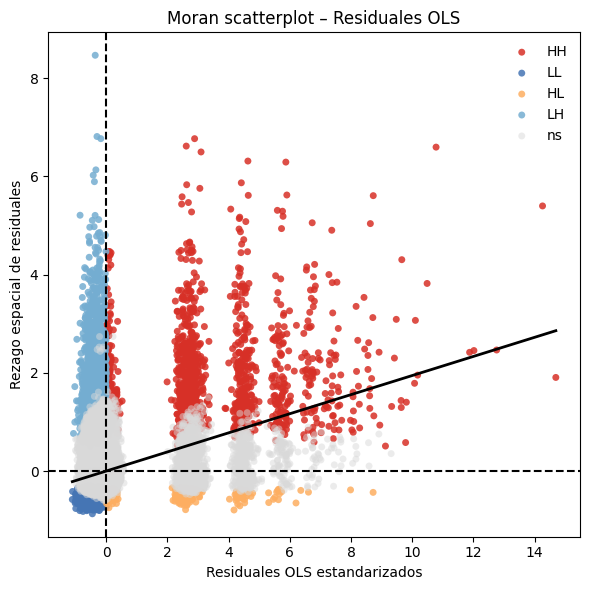

In [21]:
from esda.moran import Moran_Local
from libpysal.weights.spatial_lag import lag_spatial
import matplotlib.pyplot as plt

lisa_res = Moran_Local(res, wQ_comp, permutations=999)

# Estandarizar residual
res_std = (res - res.mean()) / res.std()
Wres    = lag_spatial(wQ_comp, res_std)

alpha = 0.05
labels = np.full(len(res), "ns", dtype=object)

for i, (q, p) in enumerate(zip(lisa_res.q, lisa_res.p_sim)):
    if p < alpha:
        labels[i] = {1:"HH", 2:"LH", 3:"LL", 4:"HL"}[q]

gdf_comp["lisa_res"] = labels


fig, ax = plt.subplots(figsize=(6, 6))

colors = {
    "HH": "#d73027",
    "LL": "#4575b4",
    "HL": "#fdae61",
    "LH": "#74add1",
    "ns": "#d9d9d9"
}

for lab, col in colors.items():
    idx = gdf_comp["lisa_res"] == lab
    ax.scatter(
        res_std[idx],
        Wres[idx],
        s=25,
        c=col,
        alpha=0.85 if lab != "ns" else 0.5,
        edgecolor="none",
        label=lab
    )

ax.axhline(0, color="k", ls="--")
ax.axvline(0, color="k", ls="--")

x = np.array([res_std.min(), res_std.max()])
ax.plot(x, moran_res.I * x, color="black", lw=2)

ax.set_xlabel("Residuales OLS estandarizados")
ax.set_ylabel("Rezago espacial de residuales")
ax.set_title("Moran scatterplot – Residuales OLS")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()



In [7]:
# %% =========================
# 2) Seleccionar columnas y limpiar
# =========================
cols = ["n_mm", "slope_mean", "aspect_mean", "geologia", "cobertura", "area"]
df = gdf[cols].copy()

# y: conteo entero >= 0
df["n_mm"] = pd.to_numeric(df["n_mm"], errors="coerce")
df = df.dropna(subset=["n_mm"])
df = df[df["n_mm"] >= 0]
df["n_mm"] = df["n_mm"].astype(int)

# numéricas
for c in ["slope_mean", "aspect_mean", "area"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# geologia: categórica (texto)
df["geologia"] = df["geologia"].astype("category")

# cobertura: dices que está en número, pero es categórica (códigos)
# la tratamos como categórica para no imponer orden ficticio (1<2<3...)
df["cobertura"] = df["cobertura"].astype("category")

# quitar filas con NA en covariables
df = df.dropna(subset=["slope_mean", "aspect_mean", "geologia", "cobertura", "area"])



# %% =========================
# 3) Transformaciones útiles
# =========================
# area en log: suele estabilizar y hacer linealidad más razonable
# (si hay áreas=0, toca corregir; normalmente no debería haber)
df = df[df["area"] > 0]
df["log_area"] = np.log(df["area"])

# Aspecto: es circular (0° ~ 360°). Mejor pasar a sin/cos.
# Si tu aspecto está en grados 0-360:
theta = np.deg2rad(df["aspect_mean"].values)
df["asp_sin"] = np.sin(theta)
df["asp_cos"] = np.cos(theta)


# %% =========================
# 4) Explorar ceros (para justificar ZI)
# =========================
p0 = (df["n_mm"] == 0).mean()
mean_y = df["n_mm"].mean()
var_y  = df["n_mm"].var()
print(f"Proporción de ceros: {p0:.3f}")
print(f"Media: {mean_y:.3f} | Varianza: {var_y:.3f} | Var/Media: {var_y/mean_y if mean_y>0 else np.nan:.3f}")

# %% =========================
# 5) Matriz X para el conteo (NB)
# =========================
# Usamos: slope_mean, asp_sin, asp_cos, log_area, geologia (dummies), cobertura (dummies)


X_num = df[["slope_mean", "asp_sin", "asp_cos", "log_area"]].astype(float)
X_cat = pd.get_dummies(df[["geologia", "cobertura"]],
                       drop_first=True,
                       dtype=float)   # <- clave
X = pd.concat([X_num, X_cat], axis=1)
X = sm.add_constant(X).astype(float)

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X[["slope_mean","asp_sin","asp_cos","log_area"]] = sc.fit_transform(
    X[["slope_mean","asp_sin","asp_cos","log_area"]]
)

y = df["n_mm"].to_numpy()


# %% =========================
# 6) Matriz Z para la inflación (logit)
# =========================
# Modelo básico: usa un subconjunto "estructural" (puedes empezar simple).
# Ejemplo: pendiente y área (y opcional geologia/cobertura)

Z = sm.add_constant(df[["slope_mean","asp_sin","asp_cos","log_area"]].astype(float)).astype(float)
#Z = sm.add_constant(pd.DataFrame({"const": np.ones(len(df))}))

# Si quieres que inflación también dependa de geologia y cobertura:
# Z = pd.concat([df[["slope_mean","log_area"]], X_cat], axis=1)
# Z = sm.add_constant(Z)

print(X.dtypes.value_counts())
print("object en X:", X.columns[X.dtypes=="object"].tolist())

print(Z.dtypes.value_counts())
print("object en Z:", Z.columns[Z.dtypes=="object"].tolist())


# %% =========================
# 7) Ajustar ZINB
# =========================
model = ZeroInflatedNegativeBinomialP(
    endog=y,
    exog=X,
    exog_infl=Z,
    inflation="logit"
)

res = model.fit(method="bfgs", maxiter=300, disp=False)
print(res.summary())


Proporción de ceros: 0.936
Media: 0.099 | Varianza: 0.254 | Var/Media: 2.579
float64    18
Name: count, dtype: int64
object en X: []
float64    5
Name: count, dtype: int64
object en Z: []
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                                 y   No. Observations:                57444
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                    57426
Method:                                      MLE   Df Model:                           17
Date:                           Tue, 30 Dec 2025   Pseudo R-squ.:                  0.1134
Time:                                   14:31:28   Log-Likelihood:                -15317.
converged:                                  True   LL-Null:                       -17276.
Covariance Type:                       nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025 

In [3]:
# %% =========================
# 8) Predicciones básicas
# =========================
df["mu_hat"] = res.predict(exog=X, exog_infl=Z, which="mean")       # E[Y]
df["p0_hat"] = res.predict(exog=X, exog_infl=Z, which="prob-zero")  # P(Y=0) total (mezcla)

print("Ceros observados (promedio):", (df["n_mm"]==0).mean())
print("Ceros predichos  (promedio):", df["p0_hat"].mean())

# %% =========================
# 9) (Opcional) Comparar con NB sin inflación
# =========================
nb = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()
print("AIC NB  :", nb.aic)
print("AIC ZINB:", res.aic)

Ceros observados (promedio): 0.9356068518905368
Ceros predichos  (promedio): 0.9355021021855497


/home/oisanchezp/geo_env/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


AIC NB  : 32181.644804268613
AIC ZINB: 31038.94355286115


In [8]:
pip install libpysal esda splot


  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 41.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd
import geopandas as gpd

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


gdf = gpd.read_file(path_gpkg, layer=layer_in)

# Si está en 4326, reproyecta a un CRS métrico local (ejemplo: MAGNA-SIRGAS / Colombia West)
if gdf.crs is None:
    raise ValueError("Tu capa no tiene CRS definido.")
    
if gdf.crs.to_epsg() == 4326:
    gdf = gdf.to_crs(3116)  # EPSG 3116 (Colombia Bogota zone). Ajusta si usas otro.


# OJO: usa el df exacto que quedó después de filtros, y construye un gdf_model consistente
gdf_model = gdf.loc[df.index].copy()


mu = res.predict(exog=X, exog_infl=Z, which="mean")  # E[Y]
gdf_model["mu_hat"] = mu
gdf_model["y_obs"] = df["n_mm"].astype(int).values


In [10]:
alpha = float(res.params["alpha"])
mu = gdf_model["mu_hat"].values
y  = gdf_model["y_obs"].values

var_nb = mu + alpha * (mu**2)
r_pearson = (y - mu) / np.sqrt(var_nb + 1e-12)

gdf_model["resid_pearson"] = r_pearson


In [11]:
r = gdf_model["resid_pearson"].values
gdf_model["resid_z"] = (r - np.nanmean(r)) / (np.nanstd(r) + 1e-12)


In [12]:
w = Queen.from_dataframe(gdf_model)
w.transform = "r"   # estandarización por filas


/tmp/ipykernel_1535555/2116252319.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_model)


('WARNING: ', 125, ' is an island (no neighbors)')
('WARNING: ', 162, ' is an island (no neighbors)')
('WARNING: ', 310, ' is an island (no neighbors)')
('WARNING: ', 1479, ' is an island (no neighbors)')
('WARNING: ', 1867, ' is an island (no neighbors)')
('WARNING: ', 1938, ' is an island (no neighbors)')
('WARNING: ', 2240, ' is an island (no neighbors)')
('WARNING: ', 2936, ' is an island (no neighbors)')
('WARNING: ', 3556, ' is an island (no neighbors)')
('WARNING: ', 3662, ' is an island (no neighbors)')
('WARNING: ', 3769, ' is an island (no neighbors)')
('WARNING: ', 4416, ' is an island (no neighbors)')
('WARNING: ', 5103, ' is an island (no neighbors)')
('WARNING: ', 5302, ' is an island (no neighbors)')
('WARNING: ', 5358, ' is an island (no neighbors)')
('WARNING: ', 5369, ' is an island (no neighbors)')
('WARNING: ', 6259, ' is an island (no neighbors)')
('WARNING: ', 6825, ' is an island (no neighbors)')
('WARNING: ', 8315, ' is an island (no neighbors)')
('WARNING: ', 8

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 205 disconnected components.
 There are 139 islands with ids: 125, 162, 310, 1479, 1867, 1938, 2240, 2936, 3556, 3662, 3769, 4416, 5103, 5302, 5358, 5369, 6259, 6825, 8315, 8550, 8629, 8781, 8908, 10694, 11616, 12816, 12985, 13281, 13945, 14244, 14727, 14732, 14806, 15615, 15834, 17869, 18347, 19584, 20158, 20247, 20262, 20339, 21096, 21793, 21983, 22255, 22490, 22782, 23187, 23355, 24187, 24303, 24319, 24370, 24397, 24815, 24950, 24974, 25132, 25158, 25828, 26085, 27426, 27456, 29052, 29584, 29627, 29733, 29817, 29891, 30415, 30626, 30702, 30835, 31020, 31180, 31472, 32294, 32301, 33111, 33154, 33603, 33968, 34459, 35169, 35286, 35670, 36866, 37212, 37550, 37659, 38289, 38652, 38711, 39239, 39488, 39770, 40183, 40489, 40490, 40963, 41246, 41569, 41583, 41881, 42792, 43787, 43891, 43960, 45021, 45264, 47042, 47197, 47621, 49039, 49574

In [13]:
x = gdf_model["resid_z"].values

mi = Moran(x, w, permutations=999)
print("Moran I:", mi.I)
print("p-value (perm):", mi.p_sim)
print("z (perm):", mi.z_sim)


Moran I: 0.13251006919161348
p-value (perm): 0.001
z (perm): 48.61289084405911


In [14]:
lisa = Moran_Local(x, w, permutations=999)

gdf_model["lisa_I"]   = lisa.Is
gdf_model["lisa_p"]   = lisa.p_sim
gdf_model["lisa_q"]   = lisa.q         # 1 HH, 2 LH, 3 LL, 4 HL (convención esda)
gdf_model["lisa_sig"] = gdf_model["lisa_p"] < 0.05


/home/oisanchezp/geo_env/lib/python3.8/site-packages/esda/moran.py:1059: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


/home/oisanchezp/geo_env/lib/python3.8/site-packages/splot/_viz_esda_mpl.py:131: UserWarning: `p` is only used for plotting `esda.moran.Moran_Local`
or `Moran_Local_BV` objects
  warnings.warn(


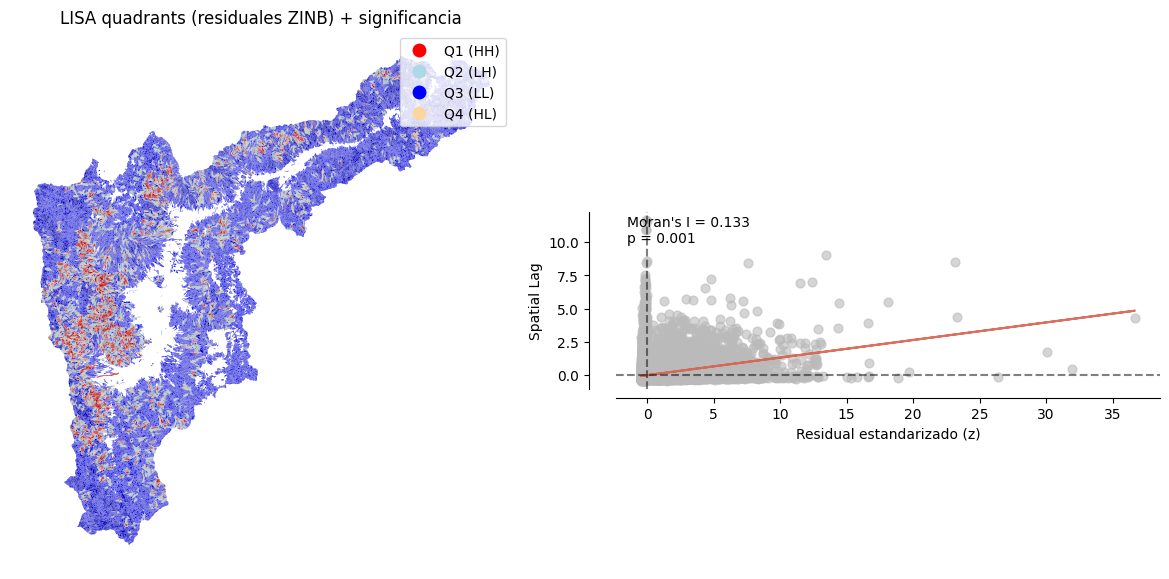

In [15]:
from matplotlib.colors import ListedColormap
from splot.esda import moran_scatterplot

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
axs = ax.flatten()

# --- Mapa de cuadrantes LISA ---
q_labels = {1:"Q1 (HH)", 2:"Q2 (LH)", 3:"Q3 (LL)", 4:"Q4 (HL)"}
gdf_model["quad"] = pd.Series(gdf_model["lisa_q"]).map(q_labels)

hmap = ListedColormap(["red", "lightblue", "blue", "#FAD7A0"])  # HH, LH, LL, HL (orden según mapping)
# Para garantizar orden consistente en leyenda, usamos categorical con categorías en orden q=1..4
order = ["Q1 (HH)", "Q2 (LH)", "Q3 (LL)", "Q4 (HL)"]
gdf_model["quad"] = pd.Categorical(gdf_model["quad"], categories=order, ordered=True)

gdf_model.plot(
    column="quad",
    categorical=True,
    cmap=hmap,
    linewidth=0.05,
    ax=axs[0],
    edgecolor="white",
    legend=True
)

# Capa de significancia (gris/no sig, negro/sig) semitransparente
sig = gdf_model["lisa_sig"].astype(int)  # 1 sig, 0 no
gdf_model.assign(sig=sig).plot(
    column="sig",
    categorical=True,
    cmap=ListedColormap(["grey", "black"]),
    linewidth=0.05,
    ax=axs[0],
    edgecolor="white",
    alpha=0.20,
    legend=False
)

axs[0].set_aspect("equal")
axs[0].set_axis_off()
axs[0].set_title("LISA quadrants (residuales ZINB) + significancia")

# --- Moran scatterplot ---
moran_scatterplot(mi, p=0.05, ax=axs[1])
axs[1].set_title("")
axs[1].set_xlabel("Residual estandarizado (z)")
axs[1].text(0.02, 0.98, f"Moran's I = {mi.I:.3f}\np = {mi.p_sim:.3g}",
            transform=axs[1].transAxes, va="top")

plt.tight_layout()
plt.show()
